In [1]:
# Import python libraries
#import json
import os
import pathlib
from glob import glob

import earthpy.api.appeears as eaapp
import earthpy
import geopandas as gpd
import hvplot.pandas
import hvplot.xarray
import pandas as pd
import rioxarray as rxr
import xarray as xr
import holoviews as hv
import matplotlib.pyplot as plt
import osmnx as osm

In [2]:
# Create a project for file management
project = earthpy.Project(
    "FVSU Vegetation",
    dirname="fvsu-vegetation"
)

In [3]:
# Search OSM for FVSU using features_by_address
fvsu_gdf = osm.features_from_address(
    'Fort Valley State University, Fort Valley, GA, United States',
    {'amenity': ['university']},
    dist=2000)
fvsu_gdf

geometry  \
element id                                                              
way     722635040   POLYGON ((-83.89489 32.54216, -83.89389 32.541...   
        1018989981  POLYGON ((-83.89842 32.54063, -83.89714 32.541...   

                      addr:city addr:country addr:housenumber addr:postcode  \
element id                                                                    
way     722635040   Fort Valley           US             1005    31030-4313   
        1018989981          NaN          NaN              NaN           NaN   

                   addr:state             addr:street     amenity  ele  \
element id                                                               
way     722635040          GA  State University Drive  university  161   
        1018989981        NaN                     NaN  university  NaN   

                   gnis:feature_id                          name  \
element id                                                         
way     722635040           355882  Fort Valley State University   
        1018989981             NaN                           NaN   

                                        operator operator:wikidata  wikidata  \
element id                                                                     
way     722635040   University System of Georgia          Q2495809  Q5472214   
        1018989981                           NaN               NaN       NaN   

                                          wikipedia  
element id                                           
way     722635040   en:Fort Valley State University  
        1018989981                              NaN

In [4]:
# Plot the data
fvsu_gdf.hvplot(geo=True, tiles="EsriImagery", alpha=0.5)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

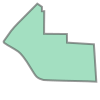

In [6]:
# Extract polygon geometry
campus_polygon = fvsu_gdf.geometry.iloc[0]
campus_polygon

In [7]:
# Search for everthing tagged as 'building' within the specified boundary
campus_buildings = osm.features_from_polygon(
    campus_polygon,
    tags={"building": True}
)

campus_buildings

geometry  \
element id                                                              
way     722635002   POLYGON ((-83.89581 32.53823, -83.8958 32.5378...   
        722635003   POLYGON ((-83.89508 32.53883, -83.89508 32.538...   
        722635004   POLYGON ((-83.89816 32.53294, -83.89812 32.533...   
        817860948   POLYGON ((-83.89562 32.53263, -83.8954 32.5326...   
        817860949   POLYGON ((-83.89906 32.5358, -83.89878 32.5358...   
...                                                               ...   
        1176271042  POLYGON ((-83.88814 32.53031, -83.88814 32.530...   
        1176271043  POLYGON ((-83.89257 32.53278, -83.89271 32.532...   
        1468103236  POLYGON ((-83.88557 32.53209, -83.88557 32.531...   
        1468103237  POLYGON ((-83.88632 32.5317, -83.88632 32.5316...   
        1468103238  POLYGON ((-83.88627 32.53169, -83.88628 32.531...   

                       amenity    building  \
element id                                   
way     722635002   restaurant  university   
        722635003      library  university   
        722635004          NaN  university   
        817860948          NaN  university   
        817860949          NaN  university   
...                        ...         ...   
        1176271042         NaN         yes   
        1176271043         NaN         yes   
        1468103236         NaN         yes   
        1468103237         NaN         yes   
        1468103238         NaN         yes   

                                                     name operator:type  \
element id                                                                
way     722635002                     Food Service Center           NaN   
        722635003                   Hunt Memorial Library    university   
        722635004   Health and Physical Education Complex           NaN   
        817860948                    Athletic Field House           NaN   
        817860949     Academic Classroom and Lab Building           NaN   
...                                                   ...           ...   
        1176271042                                    NaN           NaN   
        1176271043                                    NaN           NaN   
        1468103236                                    NaN           NaN   
        1468103237                                    NaN           NaN   
        1468103238                                    NaN           NaN   

                   demolished leisure complex                        source  
element id                                                                   
way     722635002         NaN     NaN     NaN                           NaN  
        722635003         NaN     NaN     NaN                           NaN  
        722635004         NaN     NaN     NaN                           NaN  
        817860948         NaN     NaN     NaN                           NaN  
        817860949         NaN     NaN     NaN                           NaN  
...                       ...     ...     ...                           ...  
        1176271042        NaN     NaN     NaN  microsoft/BuildingFootprints  
        1176271043        NaN     NaN     NaN  microsoft/BuildingFootprints  
        1468103236        NaN     NaN     NaN                           NaN  
        1468103237        NaN     NaN     NaN                           NaN  
        1468103238        NaN     NaN     NaN                           NaN  

[78 rows x 9 columns]

In [8]:
# Plot buildings
campus_buildings.hvplot()

:Polygons   [x,y]

In [9]:
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader = eaapp.AppeearsDownloader(
    download_key='fvsu',
    project=project,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    start_date="06-01",
    end_date="09-01",
    recurring=True,
    year_range=[2015, 2025],
    polygon=fvsu_gdf
)

In [10]:
# Download the prepared download -- this can take some time!
ndvi_downloader.download_files(cache=False)

No stored credentials found for urs.earthdata.nasa.gov. Please log in.


/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:192: UserWarning: Setting credentials not supported for 'netrc' backend.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:196: UserWarning: Failed to store credentials with 'keyring': No recommended backend was available. Install a recommended 3rd party backend package; or, install the keyrings.alt package if you want to use the non-recommended backends. See https://pypi.org/project/keyring for details.
  warnings.warn(


Credentials stored using 'env' backend.


In [11]:
# Get list of NDVI tif file paths
ndvi_paths = sorted(glob(os.path.join(
    '/workspaces/data/fvsu-vegetation/fvsu', '**', '*NDVI*.tif')))
f'{len(ndvi_paths)} NDVI paths found'

'77 NDVI paths found'

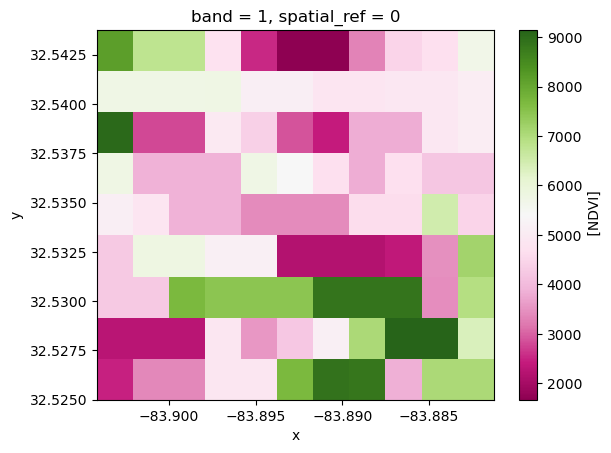

In [12]:
# Open the GeoTIFF
tif_path = "/workspaces/data/fvsu-vegetation/fvsu/MOD13Q1.061_2015137_to_2025244/MOD13Q1.061__250m_16_days_NDVI_doy2015145000000_aid0001.tif"

raster = rxr.open_rasterio(tif_path)

# Plot
raster.plot(cmap="PiYG")

plt.show()

In [13]:
from pathlib import Path

doy_start = -25
doy_end = -19

# Loop through each NDVI image
ndvi_das_dl = []
for ndvi_path in ndvi_paths:
    ndvi_path = Path(ndvi_path)

    # Get date from file name
    doy = ndvi_path.name[doy_start:doy_end]
    date = pd.to_datetime(doy, format='%Y%j')

    # Open dataset
    da = rxr.open_rasterio(ndvi_path, mask_and_scale=True).squeeze()

    # Add date dimension and clean up metadata
    da = da.assign_coords({'date': date})
    da = da.expand_dims({'date': 1})
    da.name = 'NDVI'

    # Prepare for concatenation
    ndvi_das_dl.append(da)

len(ndvi_das_dl)

77

In [14]:
# Combine NDVI images from all dates
ndvi_da = xr.combine_by_coords(ndvi_das_dl, coords=['date'])
ndvi_da

/tmp/ipykernel_5368/1684111952.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das_dl, coords=['date'])
/tmp/ipykernel_5368/1684111952.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das_dl, coords=['date'])


<xarray.Dataset> Size: 31kB
Dimensions:      (date: 77, y: 9, x: 11)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 88B -83.9 -83.9 -83.9 ... -83.89 -83.88 -83.88
  * y            (y) float64 72B 32.54 32.54 32.54 32.54 ... 32.53 32.53 32.53
    spatial_ref  int64 8B 0
  * date         (date) datetime64[ns] 616B 2015-01-14 2015-01-16 ... 2025-01-24
Data variables:
    NDVI         (date, y, x) float32 30kB 0.8167 0.6802 0.6802 ... 0.844 0.844

In [15]:
# Calculate difference in NDVI (After water rights are restored - Before)
ndvi_diff = (
    ndvi_da
        .sel(date=slice('2020', '2025'))
        .mean('date')
        .NDVI 
   - ndvi_da
        .sel(date=slice('2015', '2020'))
        .mean('date')
        .NDVI
)
print(ndvi_diff.head())

ndvi_diff_plot = (
    ndvi_diff.hvplot(x='x', y='y', cmap='PiYG', geo=True, title='FVSU - NDVI difference: 2025-2020 minus 2020-2015')
    *
    fvsu_gdf.hvplot(geo=True, fill_color=None, line_color='black')
    *
    campus_buildings.hvplot(geo=True, fill_color='None', line_color='grey')
)

ndvi_diff_plot

<xarray.DataArray 'NDVI' (y: 5, x: 5)> Size: 100B
array([[ 6.5048337e-03,  1.3793051e-02,  2.0411968e-02,  3.2778382e-02,
         3.0000031e-02],
       [-9.0479851e-05, -9.0479851e-05,  2.7042925e-02,  3.3261895e-02,
         1.3569057e-02],
       [-7.3357821e-03,  3.2897651e-02,  3.2897651e-02,  1.3546944e-03,
         1.9683421e-02],
       [ 4.4214725e-03,  1.9697547e-02,  1.4521539e-02,  1.4521539e-02,
         2.2050053e-02],
       [ 1.6183376e-02,  4.3326199e-02,  5.0761878e-02,  1.7909408e-02,
         8.5976124e-03]], dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 40B -83.9 -83.9 -83.9 -83.9 -83.89
  * y            (y) float64 40B 32.54 32.54 32.54 32.54 32.53
    spatial_ref  int64 8B 0


:Overlay
   .Image.I     :Image   [x,y]   (NDVI)
   .Polygons.I  :Polygons   [Longitude,Latitude]
   .Polygons.II :Polygons   [Longitude,Latitude]